# NB09d — Embedding Space Analysis

Deep quantitative analysis of learned embedding spaces across CNN (ResNet50), ViT, and ConvNeXt models trained on SGFood-233.

**Builds on**: NB09/09b basic t-SNE + silhouette on 5K subset  
**Goes deeper**: Full test set extraction, PCA-equalized silhouette, multi-seed t-SNE, per-class silhouette, inter-class centroid distances, correlation with accuracy.

## Tasks
1. **Feature Extraction** — Full test set (20,487 images), all 3 models
2. **Global Silhouette Scores** — High-dim + PCA-equalized comparison
3. **t-SNE with Multiple Seeds** — Stability analysis (5 seeds)
4. **Per-Class Silhouette** — Identify well/poorly separated classes
5. **Inter-Class Centroid Distances** — Confused pair proximity
6. **Correlation Analysis** — Silhouette vs accuracy relationship

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import os
from glob import glob
from pathlib import Path
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedShuffleSplit
from scipy.stats import spearmanr
from scipy.spatial.distance import cosine
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from utils import (
    Config, set_seed, get_val_transforms, LocalImageDataset,
    FoodClassifier, load_class_mapping, FeatureExtractor, extract_all_features
)

# Seed
set_seed(Config.SEED)

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Paths
DATASET_ROOT = '../foodsg-233_train_val_test_split'
NUM_CLASSES = 233
RESULTS_DIR = 'results/embedding_analysis'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Model configs (cleaned checkpoints)
MODELS = {
    'CNN (ResNet50)': {
        'name': 'resnet50',
        'checkpoint': glob('checkpoints/sgfood233_resnet50_cleaned/*.ckpt')[0],
    },
    'ViT': {
        'name': 'vit_base_patch16_224',
        'checkpoint': glob('checkpoints/sgfood233_vit_base_patch16_224_cleaned/*.ckpt')[0],
    },
    'ConvNeXt': {
        'name': 'convnext_base',
        'checkpoint': glob('checkpoints/sgfood233_convnext_base_cleaned/*.ckpt')[0],
    },
}

NUM_WORKERS = 0  # Windows

print(f'Dataset: {DATASET_ROOT}')
print(f'Results: {RESULTS_DIR}')
print(f'Classes: {NUM_CLASSES}')
print()
for name, cfg in MODELS.items():
    print(f'{name}: {cfg["checkpoint"]}')

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Dataset: ../foodsg-233_train_val_test_split
Results: results/embedding_analysis
Classes: 233

CNN (ResNet50): checkpoints/sgfood233_resnet50_cleaned\epoch=08-val_acc=0.7611.ckpt
ViT: checkpoints/sgfood233_vit_base_patch16_224_cleaned\epoch=09-val_acc=0.8103.ckpt
ConvNeXt: checkpoints/sgfood233_convnext_base_cleaned\epoch=09-val_acc=0.8455.ckpt


In [2]:
# ── Load Models & Dataset ──

# Load models
models = {}
for display_name, config in MODELS.items():
    print(f'Loading {display_name}...')
    model = FoodClassifier.load_from_checkpoint(
        config['checkpoint'],
        backbone_name=config['name'],
        num_classes=NUM_CLASSES,
    )
    model.eval()
    model.to(device)
    models[display_name] = model
    print(f'  ✓ Loaded')

# Dataset
val_transforms = get_val_transforms()
test_ds = LocalImageDataset(DATASET_ROOT, split='test', transform=val_transforms)
test_loader = DataLoader(
    test_ds, batch_size=Config.BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

# Class mapping
id2label_path = glob('checkpoints/sgfood233_convnext_base_cleaned/id2label.json')[0]
id2label = load_class_mapping(id2label_path)
label2id = {v: k for k, v in id2label.items()}
class_names = [id2label[i] for i in range(NUM_CLASSES)]

print(f'\nTest dataset: {len(test_ds)} images, {NUM_CLASSES} classes')

Loading CNN (ResNet50)...
  ✓ Loaded
Loading ViT...
  ✓ Loaded
Loading ConvNeXt...
  ✓ Loaded

Test dataset: 20487 images, 233 classes


In [3]:
# ── Task 1: Feature Extraction (full test set) ──

features_dict = {}  # display_name -> features array
labels_arr = None

for display_name, config in MODELS.items():
    print(f'\nExtracting features: {display_name}...')
    feats, labs = extract_all_features(
        models[display_name],
        config['name'],
        test_loader,
        device=device,
        max_samples=None,  # Full test set
    )
    features_dict[display_name] = feats
    if labels_arr is None:
        labels_arr = labs
    print(f'  Shape: {feats.shape}')

# Save
np.save(os.path.join(RESULTS_DIR, 'features_cnn.npy'), features_dict['CNN (ResNet50)'])
np.save(os.path.join(RESULTS_DIR, 'features_vit.npy'), features_dict['ViT'])
np.save(os.path.join(RESULTS_DIR, 'features_convnext.npy'), features_dict['ConvNeXt'])
np.save(os.path.join(RESULTS_DIR, 'labels.npy'), labels_arr)
with open(os.path.join(RESULTS_DIR, 'label_to_name.json'), 'w') as f:
    json.dump(id2label, f, indent=2)

# Verification
unique, counts = np.unique(labels_arr, return_counts=True)
print(f'\n── Verification ──')
print(f'Total samples: {len(labels_arr)}')
print(f'Unique classes: {len(unique)}')
print(f'Samples per class: min={counts.min()}, max={counts.max()}, mean={counts.mean():.1f}')
for name in ['CNN (ResNet50)', 'ViT', 'ConvNeXt']:
    print(f'{name}: {features_dict[name].shape}')


Extracting features: CNN (ResNet50)...
  Shape: (20487, 2048)

Extracting features: ViT...
  Shape: (20487, 768)

Extracting features: ConvNeXt...
  Shape: (20487, 1024)

── Verification ──
Total samples: 20487
Unique classes: 233
Samples per class: min=27, max=500, mean=87.9
CNN (ResNet50): (20487, 2048)
ViT: (20487, 768)
ConvNeXt: (20487, 1024)


## Task 2: Global Silhouette Scores

Compare cluster quality across models using silhouette scores on:
- Full high-dimensional features (cosine + euclidean)
- PCA-reduced to 256 dims (equalizes dimensionality across architectures)

In [4]:
# ── Task 2: Global Silhouette Scores ──

model_keys = ['CNN (ResNet50)', 'ViT', 'ConvNeXt']
results_global = []

# High-dimensional silhouette
for name in model_keys:
    feats = features_dict[name]
    print(f'{name} (dim={feats.shape[1]}):')
    
    sil_cos = silhouette_score(feats, labels_arr, metric='cosine')
    sil_euc = silhouette_score(feats, labels_arr, metric='euclidean')
    print(f'  Cosine: {sil_cos:.4f}  Euclidean: {sil_euc:.4f}')
    
    results_global.append({
        'model': name,
        'dim': feats.shape[1],
        'silhouette_cosine': sil_cos,
        'silhouette_euclidean': sil_euc,
    })

# PCA to 256 dims
print(f'\n── PCA Reduction to 256 dims ──')
pca_features = {}
for name in model_keys:
    feats = features_dict[name]
    n_components = min(256, feats.shape[1])
    pca = PCA(n_components=n_components, random_state=Config.SEED)
    feats_pca = pca.fit_transform(feats)
    var_explained = pca.explained_variance_ratio_.sum()
    pca_features[name] = feats_pca
    
    sil_pca = silhouette_score(feats_pca, labels_arr, metric='cosine')
    print(f'{name}: {n_components} PCs, variance explained={var_explained:.4f}, silhouette(cosine)={sil_pca:.4f}')
    
    # Update results
    for r in results_global:
        if r['model'] == name:
            r['pca_dims'] = n_components
            r['pca_variance_explained'] = var_explained
            r['silhouette_pca_cosine'] = sil_pca

# Save
df_global = pd.DataFrame(results_global)
df_global.to_csv(os.path.join(RESULTS_DIR, 'global_silhouette_scores.csv'), index=False)

print(f'\n── Summary Table ──')
print(df_global.to_string(index=False))

CNN (ResNet50) (dim=2048):
  Cosine: 0.0812  Euclidean: 0.0455
ViT (dim=768):
  Cosine: 0.1258  Euclidean: 0.0714
ConvNeXt (dim=1024):
  Cosine: 0.2496  Euclidean: 0.1515

── PCA Reduction to 256 dims ──
CNN (ResNet50): 256 PCs, variance explained=0.8556, silhouette(cosine)=0.0937
ViT: 256 PCs, variance explained=0.8633, silhouette(cosine)=0.1426
ConvNeXt: 256 PCs, variance explained=0.7956, silhouette(cosine)=0.3041

── Summary Table ──
         model  dim  silhouette_cosine  silhouette_euclidean  pca_dims  pca_variance_explained  silhouette_pca_cosine
CNN (ResNet50) 2048           0.081217              0.045463       256                0.855586               0.093694
           ViT  768           0.125828              0.071428       256                0.863292               0.142601
      ConvNeXt 1024           0.249559              0.151537       256                0.795557               0.304107


## Task 3: t-SNE with Multiple Seeds

Run t-SNE with 5 different random seeds on a stratified 5K subset to assess visualization stability. Report silhouette mean ± std.

In [6]:
# ── Task 3: t-SNE with Multiple Seeds ──

# Stratified subset (~5000 samples, every class ≥5 samples)
sss = StratifiedShuffleSplit(n_splits=1, test_size=5000, random_state=Config.SEED)
full_idx = np.arange(len(labels_arr))
_, subset_idx = next(sss.split(full_idx, labels_arr))
subset_labels = labels_arr[subset_idx]

print(f'Subset size: {len(subset_idx)}')
unique_sub, counts_sub = np.unique(subset_labels, return_counts=True)
print(f'Classes in subset: {len(unique_sub)}, min samples/class: {counts_sub.min()}')

# t-SNE with 5 seeds
SEEDS = [42, 123, 456, 789, 1024]
tsne_results = {name: {} for name in model_keys}
tsne_sil_scores = {name: [] for name in model_keys}

for name in model_keys:
    feats_sub = features_dict[name][subset_idx]
    print(f'\n{name}:')
    for seed in SEEDS:
        tsne = TSNE(n_components=2, perplexity=30, random_state=seed, max_iter=1000)
        emb_2d = tsne.fit_transform(feats_sub)
        sil = silhouette_score(emb_2d, subset_labels, metric='euclidean')
        tsne_results[name][seed] = emb_2d
        tsne_sil_scores[name].append(sil)
        print(f'  seed={seed}: silhouette={sil:.4f}')

# Summary
print(f'\n── t-SNE Silhouette Summary (mean ± std) ──')
tsne_summary = []
for name in model_keys:
    scores = tsne_sil_scores[name]
    mean, std = np.mean(scores), np.std(scores)
    print(f'{name}: {mean:.4f} ± {std:.4f}')
    tsne_summary.append({'model': name, 'mean_silhouette': mean, 'std_silhouette': std})
    for i, seed in enumerate(SEEDS):
        tsne_summary[-1][f'seed_{seed}'] = scores[i]

pd.DataFrame(tsne_summary).to_csv(os.path.join(RESULTS_DIR, 'tsne_silhouette_seeds.csv'), index=False)

Subset size: 5000
Classes in subset: 233, min samples/class: 7

CNN (ResNet50):
  seed=42: silhouette=-0.2087
  seed=123: silhouette=-0.2078
  seed=456: silhouette=-0.2077
  seed=789: silhouette=-0.2092
  seed=1024: silhouette=-0.2081

ViT:
  seed=42: silhouette=0.0082
  seed=123: silhouette=0.0071
  seed=456: silhouette=0.0064
  seed=789: silhouette=0.0102
  seed=1024: silhouette=0.0074

ConvNeXt:
  seed=42: silhouette=0.1885
  seed=123: silhouette=0.1896
  seed=456: silhouette=0.1890
  seed=789: silhouette=0.1871
  seed=1024: silhouette=0.1893

── t-SNE Silhouette Summary (mean ± std) ──
CNN (ResNet50): -0.2083 ± 0.0006
ViT: 0.0079 ± 0.0013
ConvNeXt: 0.1887 ± 0.0009


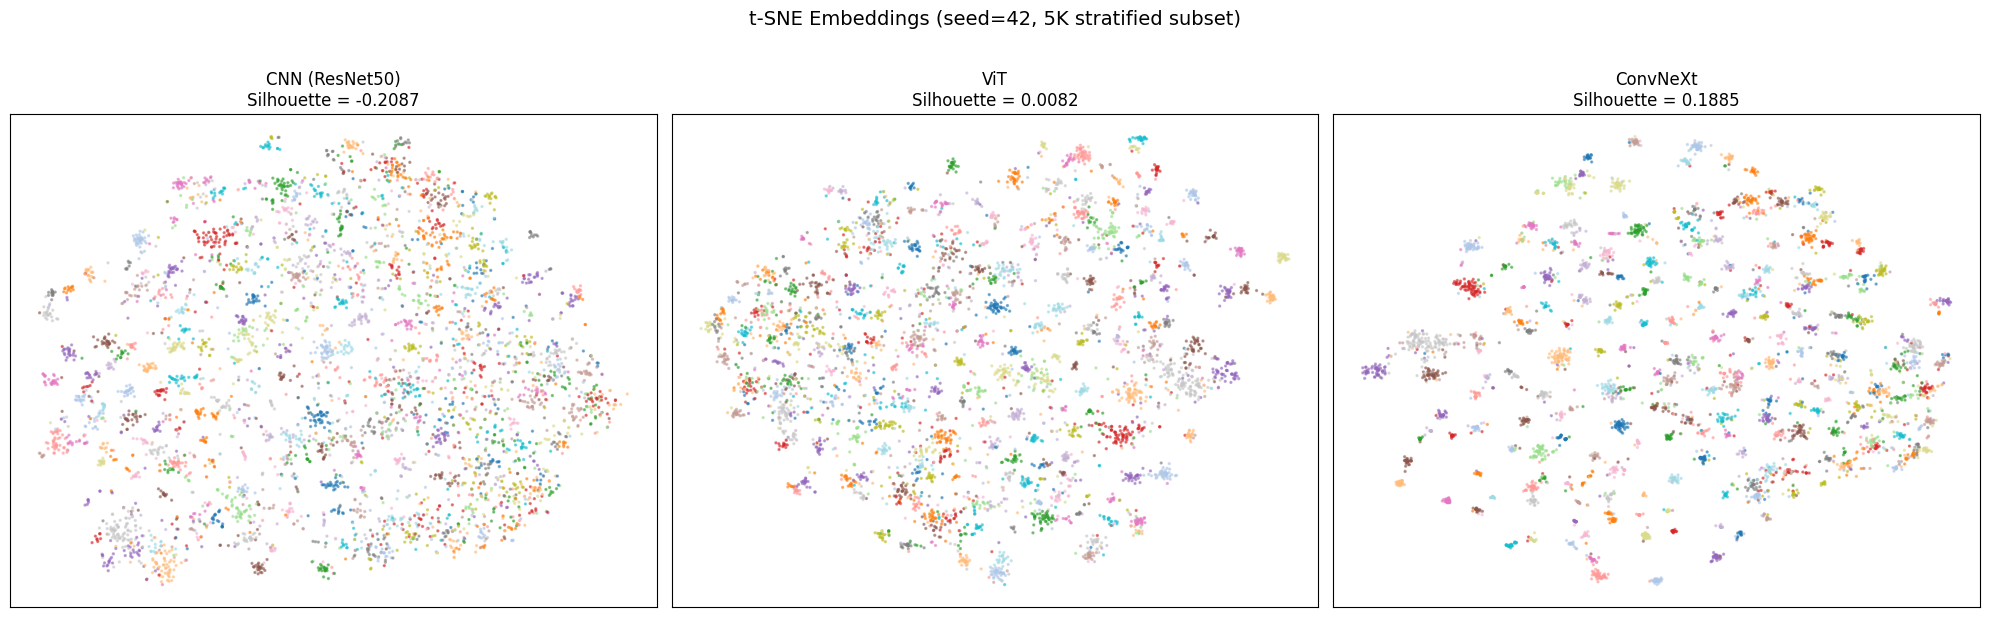

Saved tsne_plot.png and tsne_plot.pdf


In [7]:
# ── t-SNE Visualization (seed=42) ──

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Color palette — cycle tab20 for 233 classes
base_colors = plt.cm.tab20(np.linspace(0, 1, 20))
class_colors = np.array([base_colors[i % 20] for i in range(NUM_CLASSES)])
point_colors = class_colors[subset_labels]

for ax, name in zip(axes, model_keys):
    emb = tsne_results[name][42]
    ax.scatter(emb[:, 0], emb[:, 1], c=point_colors, s=2, alpha=0.5, rasterized=True)
    sil = tsne_sil_scores[name][0]  # seed=42 is first
    ax.set_title(f'{name}\nSilhouette = {sil:.4f}', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('t-SNE Embeddings (seed=42, 5K stratified subset)', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'tsne_plot.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(RESULTS_DIR, 'tsne_plot.pdf'), bbox_inches='tight')
plt.show()
print('Saved tsne_plot.png and tsne_plot.pdf')

## Task 4: Per-Class Silhouette Scores

Compute silhouette per sample, then aggregate by class. Cross-reference with per-class accuracy to find which classes are geometrically well-separated vs confused.

In [8]:
# ── Task 4: Per-Class Silhouette + Per-Class Accuracy ──

# Step 1: Per-sample silhouette scores (cosine, full high-dim)
per_sample_sil = {}
for name in model_keys:
    print(f'Computing per-sample silhouette: {name}...')
    per_sample_sil[name] = silhouette_samples(features_dict[name], labels_arr, metric='cosine')

# Step 2: Per-class mean silhouette
per_class_sil = {name: np.zeros(NUM_CLASSES) for name in model_keys}
for name in model_keys:
    for c in range(NUM_CLASSES):
        mask = labels_arr == c
        if mask.sum() > 0:
            per_class_sil[name][c] = per_sample_sil[name][mask].mean()

# Step 3: Per-class accuracy via inference
print('\nRunning inference for per-class accuracy...')
per_class_acc = {name: np.zeros(NUM_CLASSES) for name in model_keys}
per_class_counts = np.zeros(NUM_CLASSES)

for name in model_keys:
    model = models[name]
    model.eval()
    class_correct = np.zeros(NUM_CLASSES)
    class_total = np.zeros(NUM_CLASSES)
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f'{name} inference'):
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu().numpy()
            labels_np = labels.numpy()
            
            for c in range(NUM_CLASSES):
                mask = labels_np == c
                if mask.sum() > 0:
                    class_correct[c] += (preds[mask] == c).sum()
                    class_total[c] += mask.sum()
    
    for c in range(NUM_CLASSES):
        if class_total[c] > 0:
            per_class_acc[name][c] = class_correct[c] / class_total[c]
    if name == model_keys[0]:
        per_class_counts = class_total

# Build DataFrame
rows = []
for c in range(NUM_CLASSES):
    rows.append({
        'class_id': c,
        'class_name': class_names[c],
        'support': int(per_class_counts[c]),
        'cnn_silhouette': per_class_sil['CNN (ResNet50)'][c],
        'vit_silhouette': per_class_sil['ViT'][c],
        'convnext_silhouette': per_class_sil['ConvNeXt'][c],
        'cnn_acc': per_class_acc['CNN (ResNet50)'][c],
        'vit_acc': per_class_acc['ViT'][c],
        'convnext_acc': per_class_acc['ConvNeXt'][c],
    })
df_perclass = pd.DataFrame(rows)
df_perclass.to_csv(os.path.join(RESULTS_DIR, 'per_class_silhouette.csv'), index=False)

# ── Reports ──
print('\n── Top 10 Best-Separated Classes (ConvNeXt silhouette) ──')
top10_best = df_perclass.nlargest(10, 'convnext_silhouette')
for _, r in top10_best.iterrows():
    print(f'  {r["class_name"]:40s} CNN={r["cnn_silhouette"]:.3f}  ViT={r["vit_silhouette"]:.3f}  ConvNeXt={r["convnext_silhouette"]:.3f}  acc={r["convnext_acc"]:.3f}')

print('\n── Top 10 Worst-Separated Classes (ConvNeXt silhouette) ──')
top10_worst = df_perclass.nsmallest(10, 'convnext_silhouette')
for _, r in top10_worst.iterrows():
    print(f'  {r["class_name"]:40s} CNN={r["cnn_silhouette"]:.3f}  ViT={r["vit_silhouette"]:.3f}  ConvNeXt={r["convnext_silhouette"]:.3f}  acc={r["convnext_acc"]:.3f}')

# Architecture-sensitive: largest CNN-ConvNeXt gap
df_perclass['cnn_convnext_sil_gap'] = df_perclass['convnext_silhouette'] - df_perclass['cnn_silhouette']
print('\n── Top 10 Architecture-Sensitive Classes (largest CNN→ConvNeXt silhouette gain) ──')
top10_gap = df_perclass.nlargest(10, 'cnn_convnext_sil_gap')
for _, r in top10_gap.iterrows():
    print(f'  {r["class_name"]:40s} CNN={r["cnn_silhouette"]:.3f} → ConvNeXt={r["convnext_silhouette"]:.3f}  gap={r["cnn_convnext_sil_gap"]:.3f}')

# Architecture-invariant difficult (all < 0.05)
difficult = df_perclass[
    (df_perclass['cnn_silhouette'] < 0.05) &
    (df_perclass['vit_silhouette'] < 0.05) &
    (df_perclass['convnext_silhouette'] < 0.05)
]
print(f'\n── Architecture-Invariant Difficult Classes (all silhouette < 0.05): {len(difficult)} ──')
for _, r in difficult.iterrows():
    print(f'  {r["class_name"]:40s} CNN={r["cnn_silhouette"]:.3f}  ViT={r["vit_silhouette"]:.3f}  ConvNeXt={r["convnext_silhouette"]:.3f}')

# Highlighted classes from error taxonomy
highlight_queries = [
    'har cheong gai', 'ngoh hiang', 'hor fun', 'kway teow',
    'mee siam', 'bee hoon goreng', 'bee hoon soto',
    'char siew', 'steamed', 'whole wheat', 'whole grain',
    'barley', 'pitaya', 'mangosteen', 'egg tart', 'rambutan',
]
print('\n── Highlighted Classes (from error taxonomy) ──')
for query in highlight_queries:
    matches = df_perclass[df_perclass['class_name'].str.contains(query, case=False, na=False)]
    for _, r in matches.iterrows():
        print(f'  {r["class_name"]:40s} CNN_sil={r["cnn_silhouette"]:.3f}  ConvNeXt_sil={r["convnext_silhouette"]:.3f}  CNN_acc={r["cnn_acc"]:.3f}  ConvNeXt_acc={r["convnext_acc"]:.3f}')

Computing per-sample silhouette: CNN (ResNet50)...
Computing per-sample silhouette: ViT...
Computing per-sample silhouette: ConvNeXt...

Running inference for per-class accuracy...


CNN (ResNet50) inference:   0%|          | 0/321 [00:00<?, ?it/s]

ViT inference:   0%|          | 0/321 [00:00<?, ?it/s]

ConvNeXt inference:   0%|          | 0/321 [00:00<?, ?it/s]


── Top 10 Best-Separated Classes (ConvNeXt silhouette) ──
  pitaya                                   CNN=0.368  ViT=0.545  ConvNeXt=0.775  acc=0.992
  Soursop                                  CNN=0.518  ViT=0.460  ConvNeXt=0.771  acc=0.972
  mangosteen                               CNN=0.274  ViT=0.519  ConvNeXt=0.742  acc=0.990
  rambutan                                 CNN=0.434  ViT=0.475  ConvNeXt=0.688  acc=0.981
  Starfruit                                CNN=0.153  ViT=0.319  ConvNeXt=0.681  acc=0.957
  Cucumber                                 CNN=0.445  ViT=0.491  ConvNeXt=0.663  acc=0.981
  sambal kangkong                          CNN=0.528  ViT=0.442  ConvNeXt=0.657  acc=0.982
  pomegranate                              CNN=0.420  ViT=0.371  ConvNeXt=0.638  acc=1.000
  singapore sling                          CNN=0.376  ViT=0.441  ConvNeXt=0.632  acc=0.955
  guava                                    CNN=0.285  ViT=0.292  ConvNeXt=0.622  acc=0.960

── Top 10 Worst-Separated Clas

## Task 5: Inter-Class Centroid Distances

For confused class pairs from the error taxonomy, compute cosine similarity between class centroids in each model's embedding space.

In [9]:
# ── Task 5: Inter-Class Centroid Distances ──

# Compute class centroids
centroids = {}
for name in model_keys:
    feats = features_dict[name]
    cent = np.zeros((NUM_CLASSES, feats.shape[1]))
    for c in range(NUM_CLASSES):
        mask = labels_arr == c
        if mask.sum() > 0:
            cent[c] = feats[mask].mean(axis=0)
    centroids[name] = cent

# Print all 233 class names for verification
print('── All 233 class names ──')
for i, name in enumerate(class_names):
    print(f'  {i:3d}: {name}')

# Define confused pairs (from error taxonomy)
# Each tuple: (class_a_query, class_b_query, confusion_type)
confused_pairs_queries = [
    ('har cheong gai', 'fried chicken', 'Texture-similar fried'),
    ('har cheong gai', 'ngoh hiang', 'Texture-similar fried'),
    ('hor fun', 'kway teow', 'Noodle type'),
    ('bee hoon goreng', 'mee goreng', 'Fried noodle'),
    ('bee hoon soto', 'soto ayam', 'Soup noodle'),
    ('char siew pau', 'steamed bun', 'Steamed buns'),
    ('egg tart', 'dan tat', 'Pastry variant'),
    ('whole wheat bread', 'whole grain bread', 'Bread type'),
    ('pitaya', 'mangosteen', 'Exotic fruit'),
    ('barley', 'grass jelly drink', 'Brown drink'),
]

def fuzzy_find_class(query, class_names):
    """Find best matching class name (case-insensitive substring)."""
    query_lower = query.lower().replace(' ', '_')
    # Exact match first
    for i, cn in enumerate(class_names):
        if cn.lower().replace(' ', '_') == query_lower:
            return i, cn
    # Substring match
    for i, cn in enumerate(class_names):
        if query.lower() in cn.lower() or query.lower().replace(' ', '_') in cn.lower():
            return i, cn
    return None, None

# Resolve pairs
print('\n── Confused Pair Centroid Cosine Similarities ──')
print(f'{"Class A":30s} {"Class B":30s} {"CNN":>8s} {"ViT":>8s} {"ConvNeXt":>8s}  Type')
print('-' * 110)

centroid_rows = []
for q_a, q_b, pair_type in confused_pairs_queries:
    idx_a, name_a = fuzzy_find_class(q_a, class_names)
    idx_b, name_b = fuzzy_find_class(q_b, class_names)
    
    if idx_a is None or idx_b is None:
        print(f'  SKIP: could not match "{q_a}" or "{q_b}"')
        continue
    
    row = {'class_a': name_a, 'class_b': name_b, 'type': pair_type}
    sims = []
    for model_name in model_keys:
        c_a = centroids[model_name][idx_a]
        c_b = centroids[model_name][idx_b]
        sim = 1.0 - cosine(c_a, c_b)  # cosine similarity
        short_key = model_name.split('(')[0].strip() if '(' in model_name else model_name
        row[f'{short_key}_sim'] = sim
        sims.append(sim)
    
    print(f'{name_a:30s} {name_b:30s} {sims[0]:8.4f} {sims[1]:8.4f} {sims[2]:8.4f}  {pair_type}')
    centroid_rows.append(row)

df_centroids = pd.DataFrame(centroid_rows)
df_centroids.to_csv(os.path.join(RESULTS_DIR, 'centroid_distances.csv'), index=False)
print(f'\nSaved centroid_distances.csv ({len(centroid_rows)} pairs)')

── All 233 class names ──
    0: Alcoholic Beverage
    1: Apple
    2: Apricot
    3: Avocados
    4: Ban Mian
    5: Barley
    6: Bee hoon, goreng
    7: Bee hoon, soto
    8: Bibimbap
    9: Blackberry
   10: Bubble Milk Tea
   11: Burger
   12: CNY love letter
   13: Chap chye, Nonya
   14: Chinese fritters
   15: Chocolate
   16: Claypot Rice
   17: Cucumber
   18: Don, chicken teriyaki
   19: Don, unagi
   20: Duck Rice
   21: Dumpling noodle soup
   22: Fish Ball Noodles
   23: Fish and chips
   24: Fried Noodles
   25: Fruit juice
   26: Grape
   27: Grapefruit
   28: Hor Fun
   29: Indian Pancake
   30: Indian Prata
   31: Instant Cereal Drink
   32: Katsudon
   33: Kopi Teh Milo
   34: Kueh Salat
   35: Kway Teow
   36: Laksa
   37: Lontong with sayur lodeh
   38: Lor mee
   39: Macaroni
   40: Mee bandung
   41: Mee goreng
   42: Mee kuah
   43: Mee rebus
   44: Mee siam
   45: Mee siam, fried
   46: Mee soto
   47: Miso ramen, with fishcake
   48: Nasi Ambeng
   49: Nasi p

## Task 6: Correlation Analysis

Is per-class silhouette (geometric separability) predictive of per-class accuracy? Compute Spearman rank correlation.

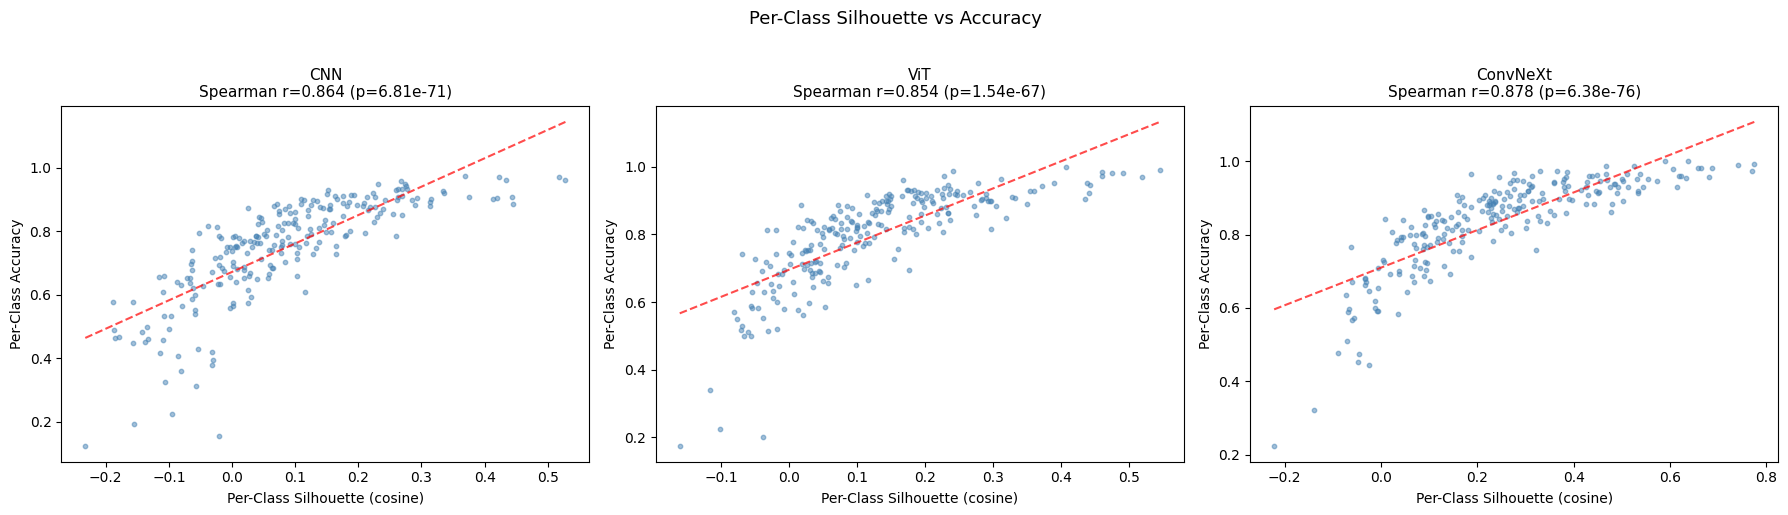


── CNN→ConvNeXt Gap Correlation ──
Spearman r = -0.1615, p = 1.36e-02
(Positive r means classes where ConvNeXt embeds better also have higher accuracy gains)

Saved correlation_results.csv
           model                         metric  spearman_r      p_value
  CNN (ResNet50)         silhouette_vs_accuracy    0.864320 6.810651e-71
             ViT         silhouette_vs_accuracy    0.854157 1.538761e-67
        ConvNeXt         silhouette_vs_accuracy    0.878149 6.378599e-76
CNN→ConvNeXt gap silhouette_gap_vs_accuracy_gap   -0.161550 1.355203e-02


In [10]:
# ── Task 6: Correlation Analysis ──

# Scatter: per-class silhouette vs per-class accuracy
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

corr_results = []
short_names = {'CNN (ResNet50)': 'CNN', 'ViT': 'ViT', 'ConvNeXt': 'ConvNeXt'}

for ax, name in zip(axes, model_keys):
    sil = per_class_sil[name]
    acc = per_class_acc[name]
    
    r, p = spearmanr(sil, acc)
    corr_results.append({
        'model': name,
        'metric': 'silhouette_vs_accuracy',
        'spearman_r': r,
        'p_value': p,
    })
    
    ax.scatter(sil, acc, s=10, alpha=0.5, c='steelblue')
    ax.set_xlabel('Per-Class Silhouette (cosine)', fontsize=10)
    ax.set_ylabel('Per-Class Accuracy', fontsize=10)
    ax.set_title(f'{short_names[name]}\nSpearman r={r:.3f} (p={p:.2e})', fontsize=11)
    
    # Trend line
    z = np.polyfit(sil, acc, 1)
    x_line = np.linspace(sil.min(), sil.max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), 'r--', alpha=0.7)

plt.suptitle('Per-Class Silhouette vs Accuracy', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'correlation_plots.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(RESULTS_DIR, 'correlation_plots.pdf'), bbox_inches='tight')
plt.show()

# CNN-ConvNeXt gap correlation
sil_gap = per_class_sil['ConvNeXt'] - per_class_sil['CNN (ResNet50)']
acc_gap = per_class_acc['ConvNeXt'] - per_class_acc['CNN (ResNet50)']
r_gap, p_gap = spearmanr(sil_gap, acc_gap)
corr_results.append({
    'model': 'CNN→ConvNeXt gap',
    'metric': 'silhouette_gap_vs_accuracy_gap',
    'spearman_r': r_gap,
    'p_value': p_gap,
})

print(f'\n── CNN→ConvNeXt Gap Correlation ──')
print(f'Spearman r = {r_gap:.4f}, p = {p_gap:.2e}')
print('(Positive r means classes where ConvNeXt embeds better also have higher accuracy gains)')

# Save
df_corr = pd.DataFrame(corr_results)
df_corr.to_csv(os.path.join(RESULTS_DIR, 'correlation_results.csv'), index=False)
print(f'\nSaved correlation_results.csv')
print(df_corr.to_string(index=False))

In [12]:
# ── Consolidated Summary ──

summary_lines = []
summary_lines.append('=' * 70)
summary_lines.append('NB09d — Embedding Space Analysis: Consolidated Summary')
summary_lines.append('=' * 70)

# Global scores
summary_lines.append('\n## 1. Global Silhouette Scores')
for _, r in df_global.iterrows():
    summary_lines.append(
        f'  {r["model"]:20s}  dim={int(r["dim"]):4d}  '
        f'cosine={r["silhouette_cosine"]:.4f}  euclidean={r["silhouette_euclidean"]:.4f}  '
        f'PCA-256={r["silhouette_pca_cosine"]:.4f} (var={r["pca_variance_explained"]:.4f})'
    )

# Ranking check
ranking = df_global.sort_values('silhouette_cosine', ascending=False)['model'].tolist()
summary_lines.append(f'\n  Ranking (cosine): {" > ".join(ranking)}')
ranking_pca = df_global.sort_values('silhouette_pca_cosine', ascending=False)['model'].tolist()
summary_lines.append(f'  Ranking (PCA-256): {" > ".join(ranking_pca)}')

# t-SNE stability
summary_lines.append('\n## 2. t-SNE Stability (5 seeds)')
for name in model_keys:
    scores = tsne_sil_scores[name]
    summary_lines.append(f'  {name:20s}  {np.mean(scores):.4f} +/- {np.std(scores):.4f}')

# Per-class highlights
summary_lines.append('\n## 3. Per-Class Silhouette Highlights')
summary_lines.append(f'  Architecture-invariant difficult (all < 0.05): {len(difficult)} classes')
for _, r in difficult.iterrows():
    summary_lines.append(f'    {r["class_name"]}')

# Correlations
summary_lines.append('\n## 4. Correlation: Silhouette vs Accuracy')
for _, r in df_corr.iterrows():
    summary_lines.append(f'  {r["model"]:25s}  r={r["spearman_r"]:.4f}  p={r["p_value"]:.2e}')

# Error taxonomy validation
summary_lines.append('\n## 5. Error Taxonomy Validation')
summary_lines.append('  Centroid similarity for confused pairs:')
for _, r in df_centroids.iterrows():
    cols = [c for c in r.index if '_sim' in c]
    sim_strs = '  '.join(f'{c}={r[c]:.3f}' for c in cols)
    summary_lines.append(f'    {r["class_a"]} <-> {r["class_b"]}: {sim_strs}  [{r["type"]}]')

summary_lines.append('\n## 6. Output Files')
for f in sorted(os.listdir(RESULTS_DIR)):
    fpath = os.path.join(RESULTS_DIR, f)
    size = os.path.getsize(fpath)
    summary_lines.append(f'  {f:40s} {size:>10,d} bytes')

summary_text = '\n'.join(summary_lines)
print(summary_text)

with open(os.path.join(RESULTS_DIR, 'summary.txt'), 'w', encoding='utf-8') as f:
    f.write(summary_text)
print(f'\nSaved summary.txt')

NB09d — Embedding Space Analysis: Consolidated Summary

## 1. Global Silhouette Scores
  CNN (ResNet50)        dim=2048  cosine=0.0812  euclidean=0.0455  PCA-256=0.0937 (var=0.8556)
  ViT                   dim= 768  cosine=0.1258  euclidean=0.0714  PCA-256=0.1426 (var=0.8633)
  ConvNeXt              dim=1024  cosine=0.2496  euclidean=0.1515  PCA-256=0.3041 (var=0.7956)

  Ranking (cosine): ConvNeXt > ViT > CNN (ResNet50)
  Ranking (PCA-256): ConvNeXt > ViT > CNN (ResNet50)

## 2. t-SNE Stability (5 seeds)
  CNN (ResNet50)        -0.2083 +/- 0.0006
  ViT                   0.0079 +/- 0.0013
  ConvNeXt              0.1887 +/- 0.0009

## 3. Per-Class Silhouette Highlights
  Architecture-invariant difficult (all < 0.05): 39 classes
    Barley
    Bee hoon, goreng
    Bee hoon, soto
    Chinese fritters
    Don, chicken teriyaki
    Duck Rice
    Dumpling noodle soup
    Hor Fun
    Katsudon
    Laksa
    Lontong with sayur lodeh
    Mee bandung
    Mee kuah
    Mee siam, fried
    Prawn Noo